# Calculate the metrics from the csv

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

# --- Define models and their respective CSV paths ---
# Updated to match the folder structure generated by make_csv.py
# (Assuming this script is run from the project root)
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

all_results = {}

# --- Run bootstrap for each ---
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    # Increased 'm' to 100 for statistically sound confidence intervals
    all_results[name] = bootstrap_from_csv(path, m=100, mode="closed")


# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename (e.g., "closed_world_results.pkl")
FILENAME = f"closed_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_results, f)

print("✅ Results saved successfully.")


Processing DINOv2 (Video)


-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [02:49<00:00,  1.70s/it]



Bootstrap Results (Closed-Set):
mAP: 52.84% ± 1.25%
Rank-1: 55.96% [53.25% - 59.18%]

Processing DINOv2 (Image)
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [02:45<00:00,  1.65s/it]


...


Bootstrap Results (Closed-Set):
mAP: 19.67% ± 0.79%
Rank-1: 18.00% [16.32% - 20.19%]

Processing ViT (Video)
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [02:33<00:00,  1.54s/it]



Bootstrap Results (Closed-Set):
mAP: 27.91% ± 0.93%
Rank-1: 26.80% [24.78% - 29.13%]

Processing ViT (Image)
-> Bootstrapping closed metrics from CSV (100 iterations)...


100%|██████████| 100/100 [02:38<00:00,  1.59s/it]


Bootstrap Results (Closed-Set):
mAP: 20.28% ± 0.74%
Rank-1: 17.64% [15.41% - 19.82%]


Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']

Model                     | mAP             | Rank-1 [100 is max]      
---------------------------------------------------------------------------
DINOv2 (Video)            | 52.8% ±1.2%     | 56.0% [53.3%-59.2%]      
DINOv2 (Image)            | 43.2% ±1.1%     | 43.3% [40.9%-46.1%]      
SwinV2 (Video)            | 25.3% ±1.0%     | 24.1% [21.7%-26.6%]      
SwinV2 (Image)            | 19.7% ±0.8%     | 18.0% [16.3%-20.2%]      
ViT (Video)               | 27.9% ±0.9%     | 26.8% [24.8%-29.1%]      
ViT (Image)               | 20.3% ±0.7%     | 17.6% [15.4%-19.8%]      


/tmp/ipykernel_1626546/2192765774.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


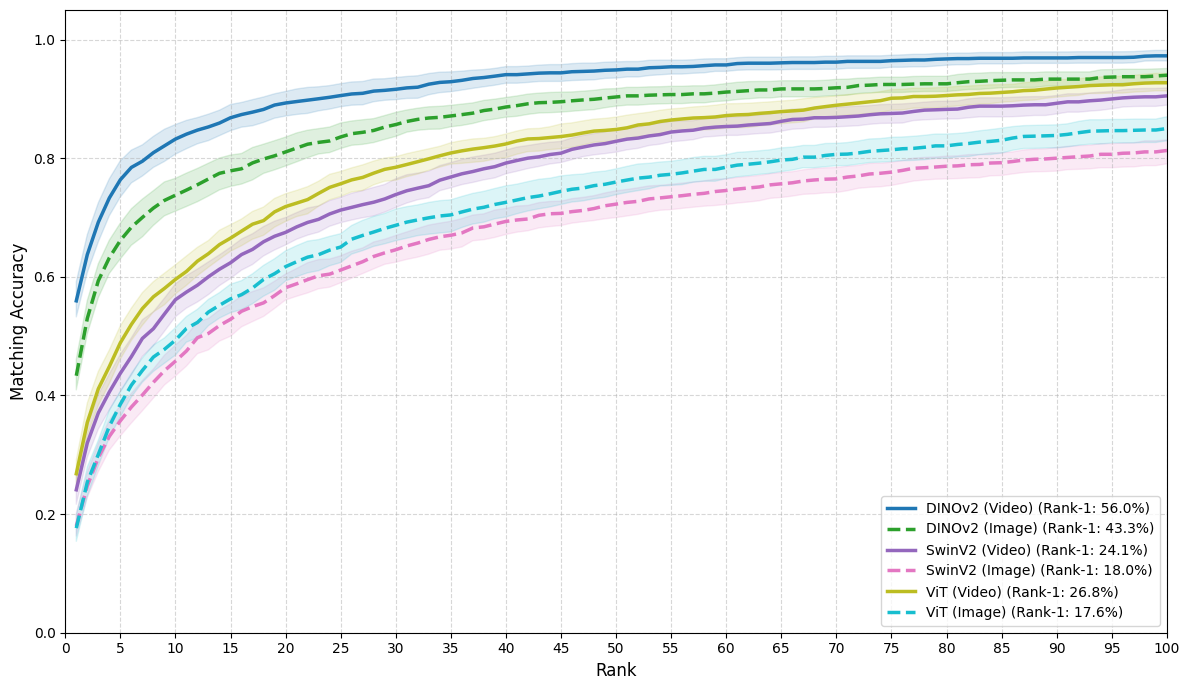

In [25]:
# Load the saved data
LOAD_PATH = "results_data/closed_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")

# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_RANK = 100      # Choose how far the X-axis goes
TICK_STEP = 5     # How frequent the numbers appear on the X-axis (e.g., 1, 2, 5)

# -------------------------------------------------------------
# --- Plotting CMC Curves with Confidence Intervals ---
# -------------------------------------------------------------

plt.figure(figsize=(12, 7))
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    ranks = res["ranks"]
    cmc_mean = res["cmc_mean"]
    cmc_lower = res["cmc_lower"]
    cmc_upper = res["cmc_upper"]
    color = colors(i)
    
    # Fill the uncertainty interval (95% CI)
    plt.fill_between(ranks, cmc_lower, cmc_upper, color=color, alpha=0.15)
    
    # Plot the Mean Line
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(ranks, cmc_mean, color=color, linestyle=line_style, linewidth=2.5, 
             label=f"{name} (Rank-1: {cmc_mean[0]:.1%})")

# Format the plot
plt.xlabel("Rank", fontsize=12)
plt.ylabel("Matching Accuracy", fontsize=12)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_RANK) 
plt.ylim(0, 1.05)
plt.xticks(np.arange(0, MAX_RANK + 1, step=TICK_STEP))

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='lower right', frameon=True)
plt.tight_layout()

# --- Print Section ---
print("\n" + "="*75)
print(f"{'Model':<25} | {'mAP':<15} | {f'Rank-1 [{MAX_RANK} is max]':<25}")
print("-" * 75)

for name, res in all_results.items():
    map_str = f"{res['mAP_mean']:.1%} ±{res['mAP_std']:.1%}"
    # Calculate Rank-1 using index 0
    r1_str = f"{res['cmc_mean'][0]:.1%} [{res['cmc_lower'][0]:.1%}-{res['cmc_upper'][0]:.1%}]"
    print(f"{name:<25} | {map_str:<15} | {r1_str:<25}")

plt.show()